In [1]:
import torch

In [2]:
class ResBlock(torch.nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.network = torch.nn.Sequential(
            torch.nn.GroupNorm(32, channels),
            torch.nn.SiLU(),
            torch.nn.Conv2d(in_channels = channels, out_channels = channels, kernel_size = 3, padding = 1),
            torch.nn.GroupNorm(32, channels),
            torch.nn.SiLU(),
            torch.nn.Conv2d(in_channels = channels, out_channels = channels, kernel_size = 3, padding = 1),
        )
    
    def forward(self, x):
        return x + self.network(x)
    

resblock = ResBlock(channels = 128)
img = torch.rand(5, 128, 256, 256)
resblock(img).shape

torch.Size([5, 128, 256, 256])

In [ ]:
class Encoder(torch.nn.Module):
    """
    Compresses (B, 3, H, W) -> (B, 8, H/8, W/8)
    Outputs 8 channels because we split into mu and logvar (4 each)
    for the reparameterization trick.
    """
    def __init__(self, ch=128, latent_channels=4):
        super().__init__()
        self.net = torch.nn.Sequential(
            # Initial projection
            torch.nn.Conv2d(in_channels = 3, out_channels = ch, kernel_size = 3, padding = 1),

            # Downsample x2
            ResBlock(ch),
            torch.nn.Conv2d(in_channels = ch, out_channels = ch*2, kernel_size = 4, stride = 2, padding = 1),   # H/2

            # Downsample x4
            ResBlock(ch*2),
            torch.nn.Conv2d(in_channels = ch*2, out_channels = ch*4, kernel_size = 4, stride = 2, padding = 1), # H/4

            # Downsample x8
            ResBlock(ch*4),
            torch.nn.Conv2d(in_channels = ch*4, out_channels = ch*4, kernel_size = 4, stride = 2, padding = 1), # H/8

            ResBlock(ch*4),

            torch.nn.GroupNorm(32, ch*4),
            torch.nn.SiLU(),
            
            # Output mu and logvar concatenated on channel dim
            torch.nn.Conv2d(in_channels = ch*4, out_channels = latent_channels * 2, kernel_size = 1),
        )

    def forward(self, x):
        h = self.net(x)
        mu, logvar = h.chunk(2, dim=1)   # each [B, 4, H/8, W/8]
        return mu, logvar                
    

encoder = Encoder(ch = 128, latent_channels = 4)
img = torch.rand(3, 3, 256, 256)
mu, logvar = encoder(img)

In [17]:
logvar.shape

torch.Size([3, 4, 32, 32])

In [22]:
print(f"{sum(p.numel() for p in encoder.parameters()):,}")

17,745,928


In [ ]:
class Decoder(torch.nn.Module):
    """
    Reconstructs [B, 4, H/8, W/8] -> [B, 3, H, W]
    """

    def __init__(self, ch=128, latent_channels=4):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels = latent_channels, out_channels = ch*4, kernel_size = 3, padding = 1),
            ResBlock(ch*4),

            # Upsample x4
            torch.nn.Upsample(scale_factor = 2, mode='nearest'),
            torch.nn.Conv2d(ch*4, ch*4, 3, padding=1),
            ResBlock(ch*4),

            # Upsample x2
            torch.nn.Upsample(scale_factor = 2, mode='nearest'),
            torch.nn.Conv2d(ch*4, ch*2, 3, padding=1),
            ResBlock(ch*2),

            # Upsample x1
            torch.nn.Upsample(scale_factor = 2, mode='nearest'),
            torch.nn.Conv2d(ch*2, ch, 3, padding=1),
            ResBlock(ch),

            torch.nn.GroupNorm(32, ch),
            torch.nn.SiLU(),
            torch.nn.Conv2d(ch, 3, 3, padding=1),
            torch.nn.Tanh(),   # output in [-1, 1]
        )

    def forward(self, z):
        return self.net(z)
    

decoder = Decoder(ch = 128, latent_channels = 4)
img_recon = torch.rand(3, 4, 32, 32)
img_recon = decoder(img_recon)
img_recon.shape

In [24]:
print(f"{sum(p.numel() for p in decoder.parameters()):,}")

14,777,603


In [7]:
class VAE(torch.nn.Module):
    def __init__(self, ch = 128, latent_channels = 4):
        super().__init__()

        self.encoder = Encoder(ch = ch, latent_channels = latent_channels)
        self.decoder = Decoder(ch = ch, latent_channels = latent_channels)

    def encode(self, normal_grid):
        mu, logvar = self.encoder(normal_grid)
        return mu, logvar
    
    def decode(self, compressed_grid):
        reconstructed_grid = self.decoder(compressed_grid)
        return reconstructed_grid

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, grid):
        mu, logvar = self.encode(normal_grid = grid)        # each [B, 4, H/8, W/8]
        z = self.reparameterize(mu = mu, logvar = logvar)   # sampling from gausian distribution
        recon_grid = self.decode(compressed_grid = z)
        return recon_grid, mu, logvar
    


In [8]:
img = torch.rand(1, 3, 256, 256)
vae = VAE(ch = 128, latent_channels = 4)
grid, mu, logvar = vae(img)

In [9]:
grid.shape

torch.Size([1, 3, 256, 256])

In [10]:
import cv2
x0 = cv2.cvtColor(cv2.resize(cv2.imread("sample_image.jpg"), (256,256)), cv2.COLOR_BGR2RGB)
x0 = (torch.tensor(x0, dtype=torch.float32) / 255.0)

x0 = torch.tensor(x0).permute(-1, 0, 1).unsqueeze(0)

grid, mu, logvar = vae(x0)

/var/folders/3p/xlr6tgyx4t980qpxnnrs12kc0000gn/T/ipykernel_79869/2791117752.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x0 = torch.tensor(x0).permute(-1, 0, 1).unsqueeze(0)


In [11]:
grid.shape

torch.Size([1, 3, 256, 256])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0019935966..1.9626749].


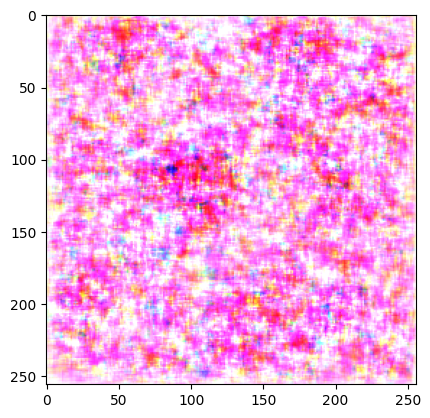

In [13]:
import matplotlib.pyplot as plt

plt.imshow(1 + grid[0].permute(1,2,0).detach().cpu().numpy())

In [30]:
print(f"{sum(p.numel() for p in vae.parameters()):,}")

32,523,531


In [ ]:
def vae_loss(recon, x, mu, logvar, kl_weight=1e-4):
    """
    - Reconstruction: how well the decoder rebuilds the input
    - KL divergence: pushes latent distribution toward N(0,I)
    """

    recon_loss = torch.nn.functional.mse_loss(recon, x, reduction='mean')

    # KL(N(mu, sigma) || N(0,1)) closed form
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    # kl_weight is small at start (KL annealing) to avoid posterior collapse
    return recon_loss + kl_weight * kl_loss